In [17]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Assumes this is run from the experiments directory with the scm package in the parent
sys.path.insert(0, '..')

from scm import SBMGenerator, CIC3Simulator
from scm import MultiRandomSeeding, MultiHighDegreeSeeding
from scm.analysis import time_discounted_attainment, exponential_decay, linear_decay, no_decay

# --- Global Parameters ---
N = 500
CORE_SIZE = 50
C = 50
BETA = 0.04
BETA_DELTA = 0.03
T_MAX = 200
NUM_TRIALS = 3  # Kept lower for the sweep, increase for final production run
V = exponential_decay(0.05)
# V = linear_decay(T_MAX)
# V = no_decay()

# --- Sweep Parameters ---
# Number of points along each axis for the 2D grid
GRID_RESOLUTION = 10 

# The 3 values for P_CORE_PERIPH (Bottleneck permeability)
P_CP_VALUES = [0.001, 0.01, 0.05] 

# Y-Axis: Core density (from sparse to near-clique)
P_CC_SWEEP = np.linspace(0.1, 0.9, GRID_RESOLUTION)

# X-Axis: Periphery intra-community density (from disconnected to moderate)
P_PI_SWEEP = np.linspace(0.01, 0.3, GRID_RESOLUTION)

In [18]:
def make_quotas_and_seeds(N_topo, C=C, seed_frac_divisor=5):
    """Distributes demand evenly with no slack (sum(quotas) == N_topo)."""
    base = N_topo // C
    rem = N_topo - base * C
    quotas = [base + 1] * rem + [base] * (C - rem)
    seeds = [max(1, q // seed_frac_divisor) for q in quotas]
    return quotas, seeds

def make_core_periphery_kwargs(p_cc, p_pi, p_cp, N=N, core_size=CORE_SIZE):
    """
    Generates the SBM block matrix and triangle probabilities for a single core
    and multiple peripheral communities.
    """
    periph_K = 9
    periph_size = (N - core_size) // periph_K
    sizes = [core_size] + [periph_size] * periph_K
    K = len(sizes)
    
    P = np.zeros((K, K))
    P[0, 0] = p_cc
    
    for i in range(1, K):
        P[0, i] = p_cp
        P[i, 0] = p_cp
        P[i, i] = p_pi
        for j in range(i + 1, K):
            P[i, j] = 0.001  # Keep inter-periphery links baseline sparse
            P[j, i] = 0.001
            
    # Triangle probability heuristic based on edge density
    T = np.zeros(K)
    T[0] = p_cc * 0.25 
    T[1:] = p_pi * 0.25
    
    return {
        "community_sizes": sizes,
        "block_matrix": P.tolist(),
        "triangle_block_probs": T.tolist()
    }

def evaluate_strategy(strat_cls, topo_links, topo_triangles, quotas, seeds):
    """Runs a single trial for a given strategy and topology."""
    seeder = strat_cls(
        N=N, num_seeds_per_contagion=seeds,
        links=topo_links, triangles=topo_triangles,
    )
    initial_infected = seeder.seed()
    
    sim = CIC3Simulator(
        links=topo_links, triangles=topo_triangles,
        initial_infected_per_contagion=initial_infected,
        betas=[BETA] * C, beta_deltas=[BETA_DELTA] * C, quotas=quotas,
    )
    sim.run(T_MAX)
    
    _, A_g_td = time_discounted_attainment(sim.infected_by, sim.infection_times, quotas, V)
    return A_g_td

In [ ]:
# Result tensor: [P_CP_index, P_CC_index, P_PI_index]
heatmap_results = np.zeros((len(P_CP_VALUES), GRID_RESOLUTION, GRID_RESOLUTION))

os.makedirs("results", exist_ok=True)
results_file = "results/cic3_core_periphery_sweep.pkl"

if os.path.exists(results_file):
    print("Loading existing sweep results...")
    with open(results_file, "rb") as f:
        heatmap_results = pickle.load(f)
else:
    print("Running parameter sweep. This will take a moment...")
    for i, p_cp in enumerate(P_CP_VALUES):
        print(f"\n[{i+1}/{len(P_CP_VALUES)}] Evaluating P_CORE_PERIPH = {p_cp}")
        for y, p_cc in enumerate(P_CC_SWEEP):
            print(f"\t[{y+1}/{len(P_CC_SWEEP)}] Evaluating P_CORE_DENSITY = {p_cc}")
            for x, p_pi in enumerate(P_PI_SWEEP):
                print(f"\t\t[{x+1}/{len(P_PI_SWEEP)}] Evaluating P_PERIPH_DENSITY = {p_pi}")
                
                sbm_kwargs = make_core_periphery_kwargs(p_cc, p_pi, p_cp)
                
                trial_deltas = []
                for _ in range(NUM_TRIALS):
                    # Instantiate INSIDE the loop to bypass the state-accumulation bug
                    gen = SBMGenerator(**sbm_kwargs)
                    links, triangles = gen.generate()
                    
                    quotas, seeds = make_quotas_and_seeds(len(links))
                    
                    ag_random = evaluate_strategy(MultiRandomSeeding, links, triangles, quotas, seeds)
                    ag_hd = evaluate_strategy(MultiHighDegreeSeeding, links, triangles, quotas, seeds)
                    
                    trial_deltas.append(ag_random - ag_hd)

                heatmap_results[i, y, x] = np.mean(trial_deltas)
                
    with open(results_file, "wb") as f:
        pickle.dump(heatmap_results, f)
    print("\nSweep complete and saved.")

Running parameter sweep. This will take a moment...

[1/3] Evaluating P_CORE_PERIPH = 0.001
	[1/10] Evaluating P_CORE_DENSITY = 0.1
		[1/10] Evaluating P_PERIPH_DENSITY = 0.01
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 355
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 927
Realized k_avg = 9.24, k_delta_avg = 5.56
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 344
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 900
Realized k_avg = 9.05, k_delta_avg = 5.40
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 338
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 938
Realized k_avg = 9.49, k_delta_avg = 5.63
CHHHHHH
BHHHHHH
		[2/10] Evaluating P_PERIPH_DENSITY = 0.042222222222222223
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 705
Sampling triangles per block-triple
SBM triangles sampled (through block 9,

KeyboardInterrupt: 

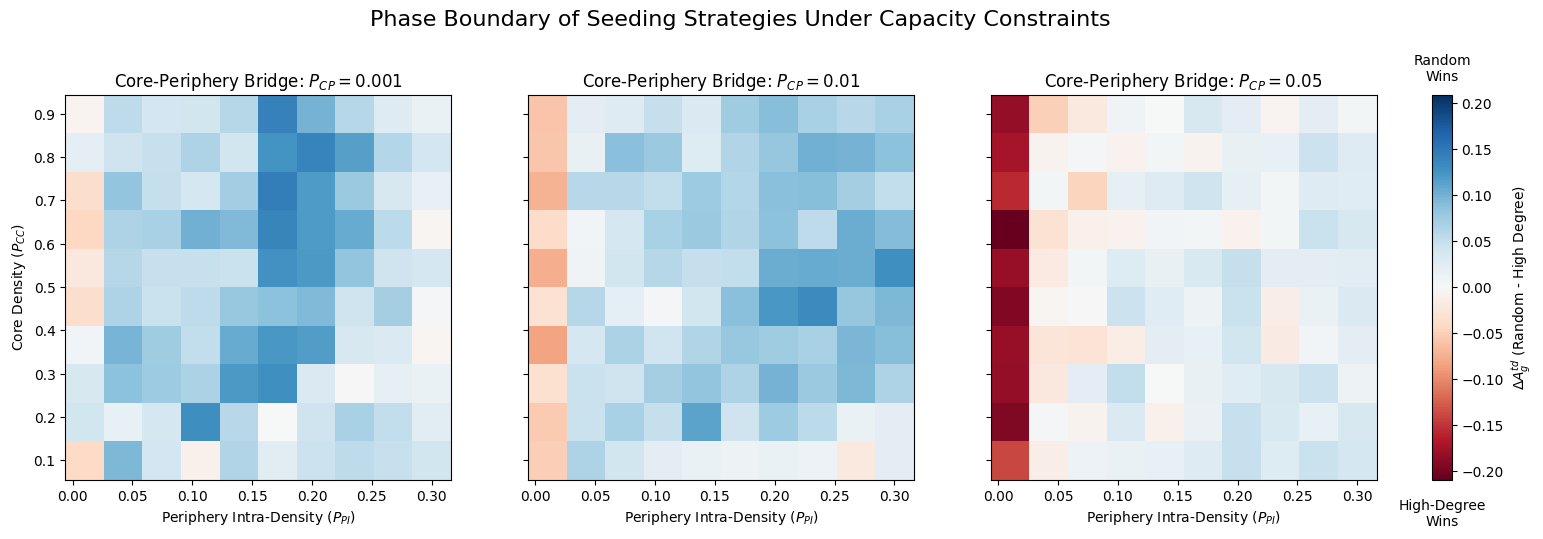

In [ ]:
# Determine color scale limits to keep the colormap centered at 0
max_abs_val = np.max(np.abs(heatmap_results))
if max_abs_val == 0:
    max_abs_val = 0.1 # Fallback to avoid zero-division in plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

X, Y = np.meshgrid(P_PI_SWEEP, P_CC_SWEEP)

for i, ax in enumerate(axes):
    p_cp = P_CP_VALUES[i]
    Z = heatmap_results[i]
    
    # Use RdBu_r: Red = High-Degree wins (negative), Blue = Random wins (positive)
    mesh = ax.pcolormesh(X, Y, Z, cmap='RdBu', vmin=-max_abs_val, vmax=max_abs_val, shading='nearest')
    
    ax.set_title(f"Core-Periphery Bridge: $P_{{CP}} = {p_cp}$")
    ax.set_xlabel("Periphery Intra-Density ($P_{PI}$)")
    
    if i == 0:
        ax.set_ylabel("Core Density ($P_{CC}$)")

# Add a single colorbar for the whole figure
cbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
cbar.set_label(r"$\Delta A_g^{td}$ (Random - High Degree)")
cbar.ax.set_title("Random\nWins", fontsize=10, pad=10)
cbar.ax.text(0.5, -0.05, "High-Degree\nWins", transform=cbar.ax.transAxes, 
             ha='center', va='top', fontsize=10)

fig.suptitle("Phase Boundary of Seeding Strategies Under Capacity Constraints", fontsize=16, y=1.05)
fig.savefig("../figures/cic3_core_periphery_sweep.png", dpi=200, bbox_inches="tight")
plt.show()